# Dynamic Asset Allocation under AI-Concentration Risk
## Markowitz vs Michaud Resampling vs Black-Litterman (optional), evaluated through the June 2026 AI/semiconductor selloff

> Companion-style notebook, built on the same methodology as the course materials
> (`Markowitz_etf.ipynb`, `Black_Litterman.ipynb`, `Frontier_Robust.ipynb`), extended to a
> **rolling, out-of-sample, periodically-rebalanced** setting on a broader multi-asset ETF
> universe.

**Research question.** Since early 2025 the US equity market has become historically
concentrated around a handful of AI/mega-cap technology names, with AI-related stocks
driving the large majority of index gains and the top names reaching an unprecedented
share of the S&P 500. This concentration was tested directly in **June 2026**, when a
sharp AI/semiconductor selloff wiped out more than a trillion dollars of market value in a
few sessions (Nasdaq Composite -2.2% to -4% in single sessions, South Korea's Kospi
briefly halted after a circuit breaker, chipmakers such as Micron and the Korean memory
producers hit hardest), with a smaller preview episode already visible on **5 February
2026**. This notebook asks: **does resampled (Michaud) or Black-Litterman portfolio
construction reduce unwanted concentration in AI/tech exposure relative to classical
Markowitz, and does that translate into better risk-adjusted, out-of-sample performance
around the June 2026 stress episode?**

**Roadmap**
1. Universe: a 19-ETF, 6-bucket multi-asset universe with an explicit AI/Tech cluster
2. Data download, inspection and cleaning
3. Estimation choices: rolling window, covariance treatment (sample vs Ledoit-Wolf)
4. Optimization engine (long-only, capped, SLSQP) reused across strategies
5. Strategy A: classical rolling Markowitz (max-Sharpe)
6. Strategy B: rolling Michaud resampling (Monte Carlo averaged weights)
7. Strategy C (optional): rolling Black-Litterman with an explicit AI-concentration view
8. Benchmarks: 60/40, 1/N (universe index), and a passive 100% QQQ reference
9. Out-of-sample performance: equity curves, drawdown, volatility, Sharpe/Sortino, turnover
10. Concentration diagnostics: HHI and AI-cluster weight over time
11. Stress-window deep dive: June 2026 (and the February 2026 preview) in isolation
12. Closing notes and suggested extensions

**A note on execution.** Like the course notebooks this file is provided as a runnable
*template* (no saved outputs) — running it requires internet access to pull data via
`yfinance`, which is not available in this authoring environment. All parameters below are
explicit and documented so the group can re-run, tune and defend every subjective choice.


## 1. Setup and imports

In [41]:
# On Colab usually only yfinance and scikit-learn need installing
!pip install -q yfinance numpy pandas scipy matplotlib seaborn scikit-learn
import warnings
warnings.filterwarnings('ignore')



In [42]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
from sklearn.covariance import LedoitWolf

np.random.seed(42)
plt.rcParams['figure.figsize'] = (11, 7)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_style('whitegrid')


## 2. ETF universe (19 names, 6 asset-class buckets)

**Why this universe.** We keep the multi-asset "skeleton" required by the assignment
(broad developed + emerging equity, government bonds short/long, IG and HY credit,
commodities/gold, real estate, cash proxy) and add a deliberate **AI/Tech cluster**
(`QQQ`, `SMH`, `XLK`, plus `EWT` and `EWY` for direct exposure to the Taiwanese and
Korean semiconductor supply chain that sits at the center of the AI trade). This lets the
optimizers *decide* how much AI-concentration risk to carry, which is exactly the
empirical question of this project.

**Why Yahoo Finance / `yfinance`.** Free, broadly used in the course materials, sufficient
history (>15y) for every name in this universe, and consistent with the baseline notebooks
so results are comparable. A Bloomberg/FactSet pull would be a natural robustness check if
available.

**Sample period.** We target the maximum common daily history across all 19 tickers,
required to be at least 15 years; see the cleaning step below for the exact aligned
window.


In [43]:
tickers = {
    # --- Broad / diversified equity ---
    'SPY':  'US Large Cap Equity',
    'IWM':  'US Small Cap Equity',
    'EFA':  'Developed ex-US Equity',
    'EEM':  'Emerging Markets Equity',
    # --- AI / Tech concentration cluster ---
    'QQQ':  'Nasdaq 100 (Mega-cap / AI Tech)',
    'SMH':  'Semiconductors',
    'XLK':  'US Technology Sector',
    'EWT':  'Taiwan Equity (semiconductor supply chain)',
    'EWY':  'South Korea Equity (memory chip supply chain)',
    # --- Government bonds ---
    'SHY':  'US Treasury 1-3y',
    'IEF':  'US Treasury 7-10y',
    'TLT':  'US Treasury 20+y',
    'TIP':  'US TIPS (inflation-linked)',
    # --- Credit ---
    'LQD':  'US Investment Grade Corporate',
    'HYG':  'US High Yield Corporate',
    # --- Real assets ---
    'GLD':  'Gold',
    'DBC':  'Broad Commodities',
    'VNQ':  'US Real Estate (REIT)',
    # --- Cash proxy ---
    'BIL':  'US T-Bill 1-3m (cash proxy)',
}
asset_names = list(tickers.keys())
n = len(asset_names)

# Asset-class buckets: used later for concentration diagnostics (HHI), for the
# Black-Litterman equilibrium prior, and as an optional budget-constraint layer
asset_class = {
    'SPY': 'Equity_Broad', 'IWM': 'Equity_Broad', 'EFA': 'Equity_Broad', 'EEM': 'Equity_Broad',
    'QQQ': 'Equity_AI_Tech', 'SMH': 'Equity_AI_Tech', 'XLK': 'Equity_AI_Tech',
    'EWT': 'Equity_AI_Tech', 'EWY': 'Equity_AI_Tech',
    'SHY': 'Govt_Bonds', 'IEF': 'Govt_Bonds', 'TLT': 'Govt_Bonds', 'TIP': 'Govt_Bonds',
    'LQD': 'Credit', 'HYG': 'Credit',
    'GLD': 'Real_Assets', 'DBC': 'Real_Assets', 'VNQ': 'Real_Assets',
    'BIL': 'Cash',
}
bucket_members = {b: [t for t in asset_names if asset_class[t] == b] for b in sorted(set(asset_class.values()))}

pd.DataFrame({
    'Asset class': [tickers[t] for t in asset_names],
    'Bucket': [asset_class[t] for t in asset_names],
}, index=asset_names)


,Asset class,Bucket
SPY,US Large Cap Equity,Equity_Broad
IWM,US Small Cap Equity,Equity_Broad
EFA,Developed ex-US Equity,Equity_Broad
EEM,Emerging Markets Equity,Equity_Broad
QQQ,Nasdaq 100 (Mega-cap / AI Tech),Equity_AI_Tech
SMH,Semiconductors,Equity_AI_Tech
XLK,US Technology Sector,Equity_AI_Tech
EWT,Taiwan Equity (semiconductor supply chain),Equity_AI_Tech
EWY,South Korea Equity (memory chip supply chain),Equity_AI_Tech
SHY,US Treasury 1-3y,Govt_Bonds


## 3. Data download, inspection and cleaning

We pull 16 years of daily prices (a 1-year buffer above the 15-year minimum), inspect
coverage per ticker, and align the panel to the **maximum common start date** so every
strategy is estimated and backtested on a perfectly synchronized panel. This is the
documented cleaning step required by the assignment.


In [44]:
raw = yf.download(asset_names, period='16y', auto_adjust=True, progress=False)
prices_daily = raw['Close'] if isinstance(raw.columns, pd.MultiIndex) else raw
prices_daily = prices_daily[asset_names]

print('Raw daily observation count per ticker:')
print(prices_daily.count())
print()
print('First valid date per ticker:')
print(prices_daily.apply(lambda s: s.first_valid_index()))


Raw daily observation count per ticker:
Ticker
SPY    4023
IWM    4023
EFA    4023
EEM    4023
QQQ    4023
SMH    4023
XLK    4023
EWT    4023
EWY    4023
SHY    4023
IEF    4023
TLT    4023
TIP    4023
LQD    4023
HYG    4023
GLD    4023
DBC    4023
VNQ    4023
BIL    4023
dtype: int64

First valid date per ticker:
Ticker
SPY   2010-07-06
IWM   2010-07-06
EFA   2010-07-06
EEM   2010-07-06
QQQ   2010-07-06
SMH   2010-07-06
XLK   2010-07-06
EWT   2010-07-06
EWY   2010-07-06
SHY   2010-07-06
IEF   2010-07-06
TLT   2010-07-06
TIP   2010-07-06
LQD   2010-07-06
HYG   2010-07-06
GLD   2010-07-06
DBC   2010-07-06
VNQ   2010-07-06
BIL   2010-07-06
dtype: datetime64[ns]


In [45]:
# --- Cleaning: align to the maximum common start date, then drop any residual NaN ---
first_valid = prices_daily.apply(lambda s: s.first_valid_index())
common_start = first_valid.max()
print(f'Latest "first valid date" across the universe: {common_start.date()}  (driven by {first_valid.idxmax()})')

prices_daily = prices_daily.loc[common_start:].dropna()
n_years = (prices_daily.index.max() - prices_daily.index.min()).days / 365.25
print(f'Aligned sample: {prices_daily.index.min().date()} -> {prices_daily.index.max().date()}')
print(f'Daily observations after cleaning: {len(prices_daily)}  (~{n_years:.1f} years)')
assert n_years >= 15, 'Sample shorter than 15 years -- drop the newest ETF and re-run.'


Latest "first valid date" across the universe: 2010-07-06  (driven by SPY)
Aligned sample: 2010-07-06 -> 2026-07-02
Daily observations after cleaning: 4023  (~16.0 years)


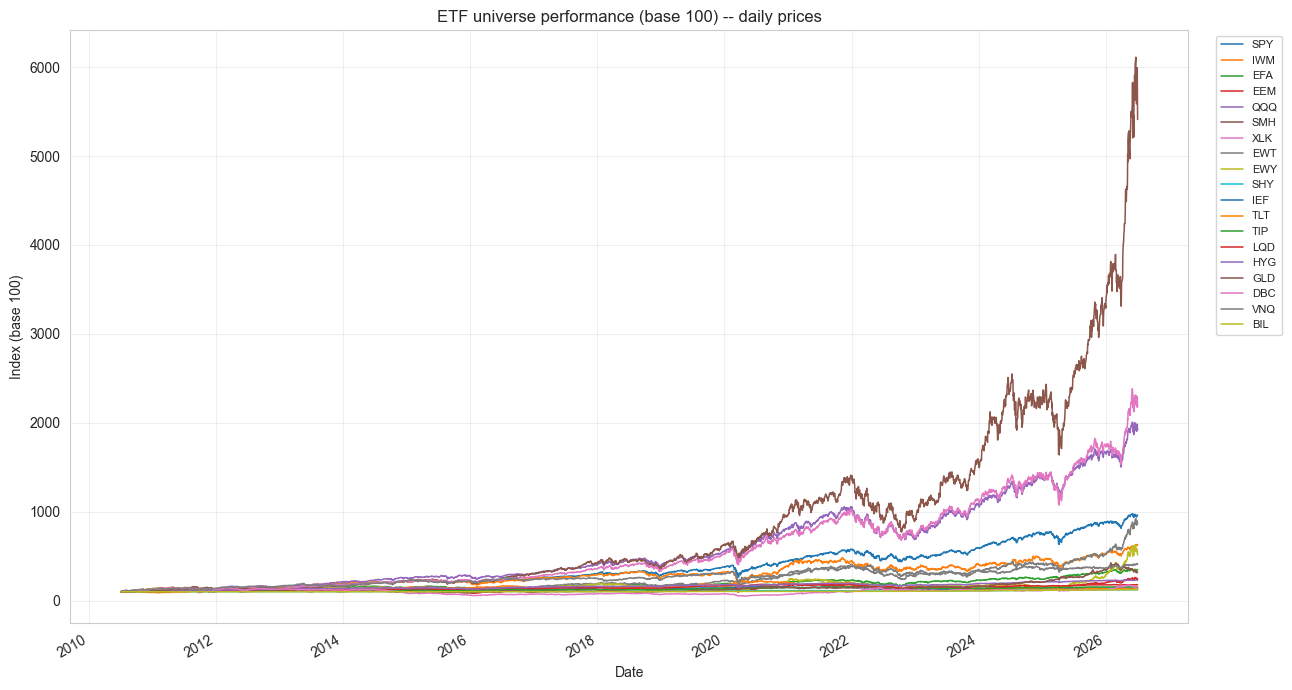

In [46]:
# Quick visual inspection: normalized prices (base 100)
(prices_daily / prices_daily.iloc[0] * 100).plot(figsize=(13, 7), lw=1.1,
    title='ETF universe performance (base 100) -- daily prices')
plt.ylabel('Index (base 100)')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()


## 4. Monthly returns

As in the baseline course notebook, we resample to **month-end** and use monthly log
returns for estimation: closer to i.i.d./normal, less microstructure noise, and a more
robust x12 / sqrt(12) annualization than daily-based estimates.


In [47]:
monthly_prices = prices_daily.resample('ME').last()
rets_m = np.log(monthly_prices / monthly_prices.shift(1)).dropna()
MONTHS_PER_YEAR = 12
T = len(rets_m)
print(f'Monthly observations: {T}  ({rets_m.index.min().date()} -> {rets_m.index.max().date()})')
rets_m.tail()


Monthly observations: 192  (2010-08-31 -> 2026-07-31)


Ticker,SPY,IWM,EFA,EEM,QQQ,SMH,XLK,EWT,EWY,SHY,IEF,TLT,TIP,LQD,HYG,GLD,DBC,VNQ,BIL
Date,,,,,,,,,,,,,,,,,,,
2026-03-31,-0.050640,-0.050884,-0.081523,-0.097086,-0.049592,-0.058185,-0.041906,-0.064829,-0.207461,-0.004676,-0.023475,-0.043221,-0.013679,-0.020946,-0.009582,-0.117109,0.142702,-0.065221,0.002874
2026-04-30,0.099893,0.114084,0.052055,0.119367,0.145745,0.278880,0.182447,0.236923,0.267647,0.001905,-0.001504,-0.008432,0.010815,0.002815,0.015092,-0.015528,0.071638,0.082520,0.002885
2026-05-31,0.051288,0.043849,0.023949,0.069566,0.100465,0.167186,0.180334,0.134115,0.247138,0.000766,-0.000190,0.005320,0.001899,0.008587,0.004355,-0.015557,-0.053496,-0.006562,0.003169
2026-06-30,-0.010346,0.036294,0.006883,0.002411,-0.001492,0.090848,-0.001429,0.055173,-0.019278,0.000646,0.002509,0.011592,-0.004577,0.001128,0.000863,-0.124259,-0.100548,0.016374,0.002721
2026-07-31,-0.002668,-0.009598,0.004706,-0.040420,-0.032853,-0.101997,-0.053528,-0.035137,-0.114038,0.000830,-0.001476,-0.006899,-0.000388,-0.000442,0.001368,0.026123,-0.003382,0.016354,0.000744


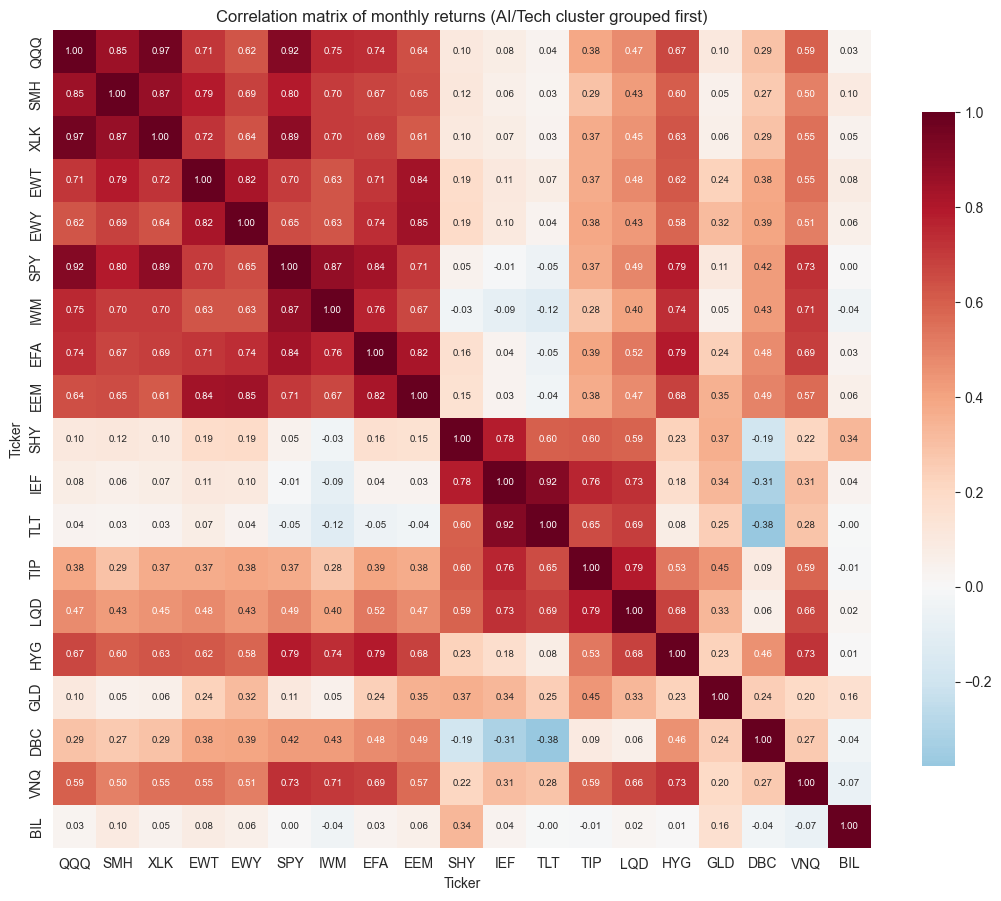

In [48]:
# Correlation matrix, with the AI/Tech cluster visually grouped first
ordered_cols = bucket_members['Equity_AI_Tech'] + [t for t in asset_names if asset_class[t] != 'Equity_AI_Tech']
corr = rets_m[ordered_cols].corr()
plt.figure(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, square=True,
            cbar_kws={'shrink': 0.8}, annot_kws={'fontsize': 7})
plt.title('Correlation matrix of monthly returns (AI/Tech cluster grouped first)')
plt.tight_layout()
plt.show()


## 5. Estimation choices (the subjective parameters, made explicit)

- **Rolling window** for `mu`/`Sigma` estimation: `WINDOW_MONTHS = 60` (5 years). A shorter
  window reacts faster to regime change (like the AI buildout) but is noisier; a longer
  window is more stable but slower to reflect the new regime. Try 36 or 84 months as a
  robustness check.
- **Rebalancing frequency**: `REBAL_EVERY = 1` (monthly). Set to 3 for quarterly.
- **Covariance treatment**: `COV_METHOD = 'lw'` (Ledoit-Wolf shrinkage). This universe
  contains several highly correlated names by construction (`QQQ`, `SMH`, `XLK` all load
  heavily on the same AI factor), which makes the raw sample covariance matrix
  ill-conditioned on a 5-year monthly window (60 observations, 19 assets). Shrinkage keeps
  the optimizer numerically stable and is the fairer baseline for comparing Markowitz vs
  Michaud (otherwise Markowitz instability is partly a covariance-estimation artifact
  rather than a genuine mean-estimation one).
- **Constraints**: long-only, no leverage, `W_CAP = 0.30` maximum weight per single ETF.


In [49]:
def estimate_mu_sigma(window_rets, method='lw'):
    '''Annualized (mu, Sigma) estimated from a trailing window of monthly log returns.'''
    mu_hat = window_rets.mean().values * MONTHS_PER_YEAR
    if method == 'sample':
        Sigma_hat = window_rets.cov().values * MONTHS_PER_YEAR
    elif method == 'lw':
        lw = LedoitWolf().fit(window_rets.values)
        Sigma_hat = lw.covariance_ * MONTHS_PER_YEAR
    else:
        raise ValueError("method must be 'sample' or 'lw'")
    return mu_hat, Sigma_hat

COV_METHOD = 'lw'      # 'sample' or 'lw'  -- subjective choice, documented above
WINDOW_MONTHS = 60      # 5-year rolling estimation window -- subjective choice
REBAL_EVERY = 1         # 1 = monthly, 3 = quarterly -- subjective choice
W_CAP = 0.30            # long-only weight cap per single ETF -- subjective choice


## 6. Optimization engine

Same SLSQP machinery as the baseline notebooks. We implement the classical Markowitz
strategy as the **long-only, capped, maximum-Sharpe** portfolio (one of the three variants
suggested by the assignment; min-variance or a target-volatility grid are direct
alternatives using the same helpers).


In [50]:
def portfolio_variance(w, S):
    return w @ S @ w

def neg_sharpe(w, mu_v, S):
    return -(w @ mu_v) / np.sqrt(w @ S @ w)

def max_sharpe_weights(mu_v, S, w_cap=W_CAP):
    n_ = len(mu_v)
    w0 = np.ones(n_) / n_
    cons = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1}]
    bounds = [(0.0, w_cap)] * n_
    res = minimize(neg_sharpe, w0, args=(mu_v, S), method='SLSQP',
                   bounds=bounds, constraints=cons,
                   options={'ftol': 1e-10, 'maxiter': 500})
    return res.x if res.success else np.ones(n_) / n_   # fallback: equal weight

def min_var_weights(mu_v, S, w_cap=W_CAP):
    n_ = len(mu_v)
    w0 = np.ones(n_) / n_
    cons = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1}]
    bounds = [(0.0, w_cap)] * n_
    res = minimize(portfolio_variance, w0, args=(S,), method='SLSQP',
                   bounds=bounds, constraints=cons,
                   options={'ftol': 1e-10, 'maxiter': 500})
    return res.x if res.success else np.ones(n_) / n_


## 7. Rolling, out-of-sample backtest engine

At each rebalancing date `t`, weights are computed using **only** information available up
to `t` (the trailing `WINDOW_MONTHS` window), then held and applied to the **realized**
returns of the following period(s) until the next rebalance. This is the no-look-ahead
discipline required by the assignment.


In [51]:
rebalance_idx = list(range(WINDOW_MONTHS, T, REBAL_EVERY))
rebalance_dates = rets_m.index[rebalance_idx]
print(f'{len(rebalance_dates)} rebalancing dates, from {rebalance_dates[0].date()} to {rebalance_dates[-1].date()}')
print(f'(the first {WINDOW_MONTHS} months are used only to estimate mu/Sigma for the first rebalance)')


132 rebalancing dates, from 2015-08-31 to 2026-07-31
(the first 60 months are used only to estimate mu/Sigma for the first rebalance)


In [52]:
def run_rolling_backtest(strategy_fn, name, **kwargs):
    '''Generic rolling engine, reused by every strategy below.'''
    W_hist = pd.DataFrame(index=rebalance_dates, columns=asset_names, dtype=float)
    port_rets = pd.Series(index=rets_m.index, dtype=float)

    for j, t_idx in enumerate(rebalance_idx):
        window = rets_m.iloc[t_idx - WINDOW_MONTHS: t_idx]
        mu_hat, Sigma_hat = estimate_mu_sigma(window, method=COV_METHOD)
        w = strategy_fn(mu_hat, Sigma_hat, **kwargs)
        W_hist.iloc[j] = w

        start = t_idx
        end = rebalance_idx[j + 1] if j + 1 < len(rebalance_idx) else T
        for k in range(start, end):
            port_rets.iloc[k] = rets_m.iloc[k].values @ w

    port_rets = port_rets.dropna()
    print(f'{name}: backtested {len(port_rets)} monthly periods over {len(rebalance_dates)} rebalances')
    return W_hist, port_rets


## 8. Strategy A -- classical rolling Markowitz (max-Sharpe, long-only, capped)

In [53]:
def strategy_markowitz(mu_hat, Sigma_hat):
    return max_sharpe_weights(mu_hat, Sigma_hat)

W_mkw, ret_mkw = run_rolling_backtest(strategy_markowitz, 'Classical Markowitz')


Classical Markowitz: backtested 132 monthly periods over 132 rebalances


## 9. Strategy B -- Michaud resampled frontier (rolling)

At each rebalance date we simulate `B_PATHS` alternative monthly-return histories from
`N(mu_hat/12, Sigma_hat/12)`, re-estimate `(mu_b, Sigma_b)` on each simulated history,
solve the same max-Sharpe problem on each, and **average the resulting weights**. This
directly targets estimation risk in `mu_hat` -- the dominant source of Markowitz
instability -- rather than the covariance matrix, which is already being shrunk.


In [54]:
B_PATHS = 300   # number of Monte Carlo resamples per rebalance -- subjective choice
                # (300-1000 is typical; kept moderate here for runtime; try 1000 for a
                # smoother -- but slower -- averaged frontier)

def strategy_michaud(mu_hat, Sigma_hat, B=B_PATHS, T_sim=WINDOW_MONTHS):
    mu_m = mu_hat / MONTHS_PER_YEAR
    S_m = Sigma_hat / MONTHS_PER_YEAR
    W_sim = np.zeros((B, n))
    for b in range(B):
        sim = np.random.multivariate_normal(mu_m, S_m, size=T_sim)
        mu_b = sim.mean(axis=0) * MONTHS_PER_YEAR
        S_b = np.cov(sim.T) * MONTHS_PER_YEAR
        W_sim[b] = max_sharpe_weights(mu_b, S_b)
    w_avg = W_sim.mean(axis=0)
    return w_avg / w_avg.sum()

W_mic, ret_mic = run_rolling_backtest(strategy_michaud, 'Michaud resampled')


Michaud resampled: backtested 132 monthly periods over 132 rebalances


## 10. Strategy C (optional) -- rolling Black-Litterman with an AI-concentration view

Following the same derivation as the course's `Black_Litterman.ipynb`:

- **Equilibrium weights `w_eq`**: a fixed strategic multi-asset allocation across the 6
  buckets (35% broad equity, 15% AI/Tech, 25% govt bonds, 10% credit, 10% real assets, 5%
  cash), split equally within each bucket. This is the "neutral" benchmark an
  equilibrium-based investor would hold absent tactical views.
- **Prior `Pi`**: reverse optimization, `Pi = delta * Sigma_hat @ w_eq`, with `delta = 2.5`
  (in line with the Drobetz / He-Litterman convention used in the course notebook).
- **The view**: a single, moderate-confidence, *cautionary* relative view -- **the AI/Tech
  cluster will underperform broad equity by 2%/year** relative to what trailing history
  suggests -- directly encoding the concentration-risk narrative motivating this project.
- **`Omega`**: He-Litterman convention, `Omega = diag(P * tau * Sigma_hat * P')`.
- **`tau = 0.03`**: fairly tight prior, consistent with the 0.025-0.05 range used in the
  course notebook and by Drobetz/He-Litterman.


In [55]:
w_eq_bucket = {
    'Equity_Broad': 0.35, 'Equity_AI_Tech': 0.15, 'Govt_Bonds': 0.25,
    'Credit': 0.10, 'Real_Assets': 0.10, 'Cash': 0.05,
}
w_eq = np.array([w_eq_bucket[asset_class[t]] / len(bucket_members[asset_class[t]]) for t in asset_names])
print(f'Equilibrium weights sum to {w_eq.sum():.4f}')

ai_names = bucket_members['Equity_AI_Tech']
broad_names = bucket_members['Equity_Broad']
P_view = np.zeros(n)
for t in ai_names:
    P_view[asset_names.index(t)] = 1.0 / len(ai_names)
for t in broad_names:
    P_view[asset_names.index(t)] = -1.0 / len(broad_names)
P_view = P_view.reshape(1, -1)
Q_view = np.array([-0.02])   # AI/Tech cluster underperforms broad equity by 2%/yr
TAU = 0.03

def strategy_black_litterman(mu_hat, Sigma_hat, delta=2.5):
    inv = np.linalg.inv
    Omega = np.diag(np.diag(P_view @ (TAU * Sigma_hat) @ P_view.T))
    Pi = delta * Sigma_hat @ w_eq
    M = inv(inv(TAU * Sigma_hat) + P_view.T @ inv(Omega) @ P_view)
    mu_BL = M @ (inv(TAU * Sigma_hat) @ Pi + P_view.T @ inv(Omega) @ Q_view)
    Sigma_BL = Sigma_hat + M
    return max_sharpe_weights(mu_BL, Sigma_BL)

W_bl, ret_bl = run_rolling_backtest(strategy_black_litterman, 'Black-Litterman (AI-concentration view)')


Equilibrium weights sum to 1.0000
Black-Litterman (AI-concentration view): backtested 132 monthly periods over 132 rebalances


## 11. Benchmarks

Required by the assignment: at least one naive benchmark, rebalanced at the same
frequency, **plus** a benchmark representing the chosen universe itself.

- **60/40**: 60% `SPY` / 40% `IEF`, classic naive benchmark.
- **1/N**: equal-weight across all 19 ETFs, rebalanced monthly -- this *is* the "index
  representing the chosen universe" requested by the assignment.
- **100% QQQ** (reference only, not a real benchmark): shows what "just riding the AI
  rally" would have delivered, i.e. the concentration risk being actively managed by the
  three strategies above.


In [56]:
def strategy_6040(mu_hat, Sigma_hat):
    w = np.zeros(n)
    w[asset_names.index('SPY')] = 0.60
    w[asset_names.index('IEF')] = 0.40
    return w

def strategy_1n(mu_hat, Sigma_hat):
    return np.ones(n) / n

W_6040, ret_6040 = run_rolling_backtest(strategy_6040, '60/40 benchmark')
W_1n, ret_1n = run_rolling_backtest(strategy_1n, '1/N universe-index benchmark')
ret_qqq = rets_m['QQQ'].loc[ret_mkw.index]


60/40 benchmark: backtested 132 monthly periods over 132 rebalances
1/N universe-index benchmark: backtested 132 monthly periods over 132 rebalances


## 12. Out-of-sample performance measures

Cumulative return, annualized volatility, Sharpe, Sortino, max drawdown, Calmar, average
turnover per rebalance, and average portfolio concentration (Herfindahl-Hirschman Index,
`HHI = sum(w_i^2)`: 1/19 = 0.053 is fully diversified, 1.0 is a single-asset portfolio).


In [57]:
def perf_summary(ret, name):
    ann_ret = ret.mean() * MONTHS_PER_YEAR
    ann_vol = ret.std() * np.sqrt(MONTHS_PER_YEAR)
    sharpe = ann_ret / ann_vol
    downside = ret[ret < 0].std() * np.sqrt(MONTHS_PER_YEAR)
    sortino = ann_ret / downside if downside and downside > 0 else np.nan
    cum = (1 + ret).cumprod()
    dd = cum / cum.cummax() - 1
    max_dd = dd.min()
    calmar = ann_ret / abs(max_dd) if max_dd < 0 else np.nan
    return pd.Series({'Ann. Return': ann_ret, 'Ann. Vol': ann_vol, 'Sharpe': sharpe,
                      'Sortino': sortino, 'Max Drawdown': max_dd, 'Calmar': calmar}, name=name)

def turnover_avg(W_hist):
    return W_hist.diff().abs().sum(axis=1).mean()

def hhi_avg(W_hist):
    return (W_hist ** 2).sum(axis=1).mean()

strategies = {
    'Markowitz':            (ret_mkw, W_mkw),
    'Michaud':              (ret_mic, W_mic),
    'Black-Litterman':      (ret_bl, W_bl),
    '60/40':                (ret_6040, W_6040),
    '1/N (universe index)': (ret_1n, W_1n),
}

summary = pd.concat([perf_summary(r, name) for name, (r, w) in strategies.items()], axis=1)
summary.loc['Avg. Turnover'] = [turnover_avg(w) for name, (r, w) in strategies.items()]
summary.loc['Avg. HHI'] = [hhi_avg(w) for name, (r, w) in strategies.items()]
summary.T.style.format('{:.3f}')


,Ann. Return,Ann. Vol,Sharpe,Sortino,Max Drawdown,Calmar,Avg. Turnover,Avg. HHI
Markowitz,0.075,0.071,1.064,1.592,-0.172,0.438,0.149,0.185
Michaud,0.069,0.064,1.077,1.547,-0.165,0.415,0.112,0.123
Black-Litterman,0.061,0.112,0.541,0.669,-0.224,0.271,0.075,0.140
60/40,0.083,0.098,0.850,1.204,-0.216,0.386,0.000,0.520
1/N (universe index),0.091,0.108,0.842,1.191,-0.234,0.388,0.000,0.053


## 13. Equity curves, drawdown and rolling volatility

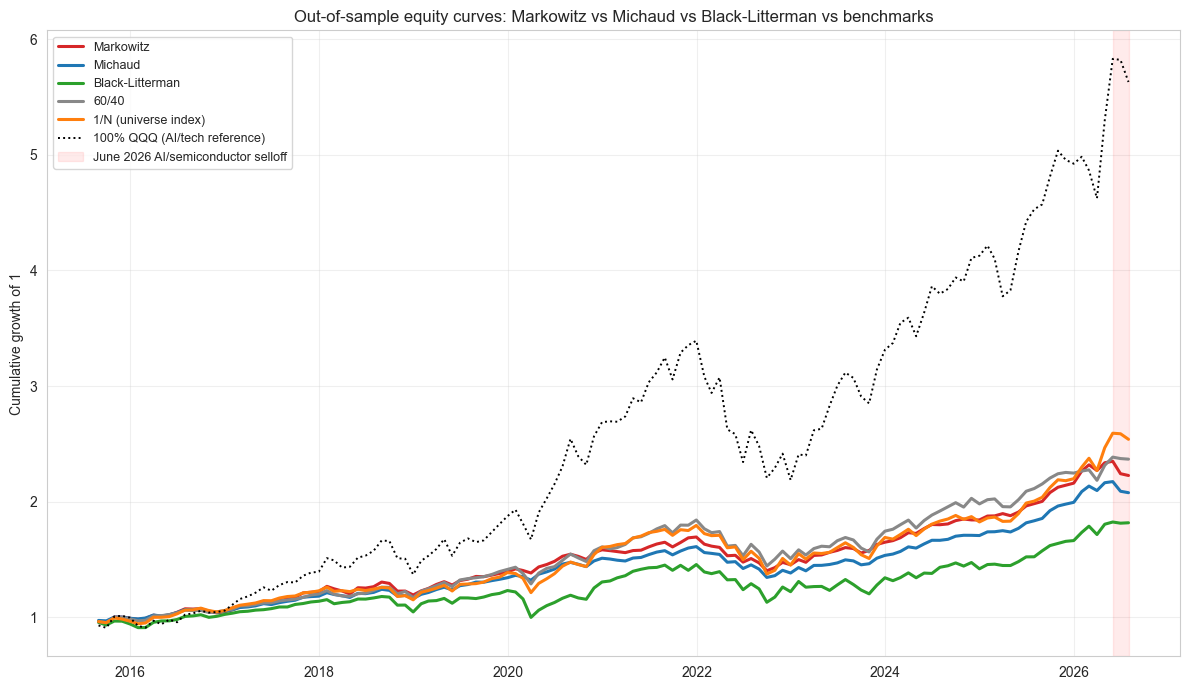

In [58]:
colors_map = {'Markowitz': '#d62728', 'Michaud': '#1f77b4', 'Black-Litterman': '#2ca02c',
             '60/40': '#888888', '1/N (universe index)': '#ff7f0e'}

fig, ax = plt.subplots(figsize=(12, 7))
for name, (r, w) in strategies.items():
    cum = (1 + r).cumprod()
    ax.plot(cum.index, cum.values, lw=2.2, label=name, color=colors_map.get(name))
cum_qqq = (1 + ret_qqq).cumprod()
ax.plot(cum_qqq.index, cum_qqq.values, lw=1.4, ls=':', color='black', label='100% QQQ (AI/tech reference)')
ax.axvspan(pd.Timestamp('2026-06-01'), pd.Timestamp('2026-07-31'), color='red', alpha=0.08,
          label='June 2026 AI/semiconductor selloff')
ax.set_ylabel('Cumulative growth of 1')
ax.set_title('Out-of-sample equity curves: Markowitz vs Michaud vs Black-Litterman vs benchmarks')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()


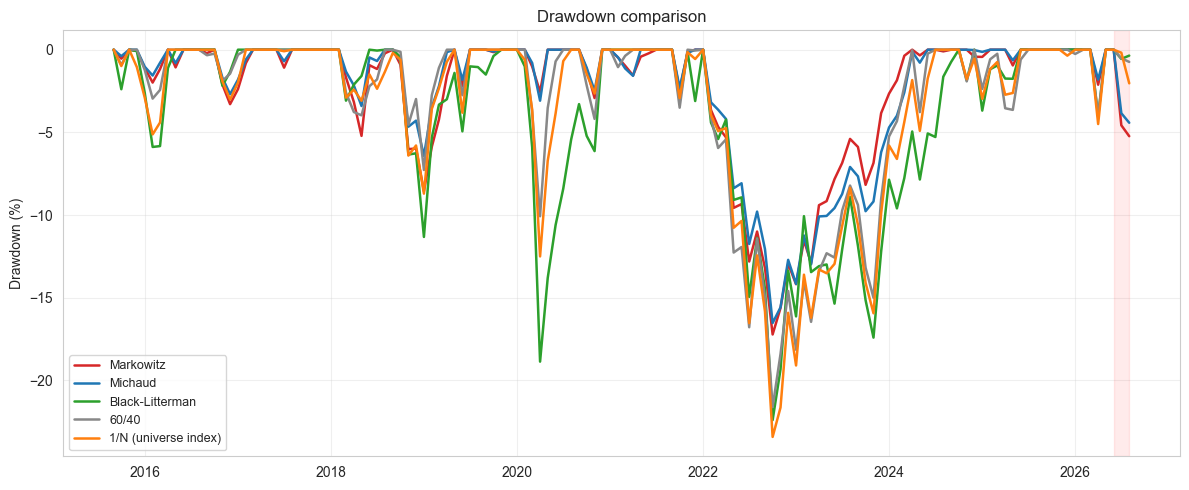

In [59]:
fig, ax = plt.subplots(figsize=(12, 5))
for name, (r, w) in strategies.items():
    cum = (1 + r).cumprod()
    dd = cum / cum.cummax() - 1
    ax.plot(dd.index, dd.values * 100, lw=1.8, label=name, color=colors_map.get(name))
ax.axvspan(pd.Timestamp('2026-06-01'), pd.Timestamp('2026-07-31'), color='red', alpha=0.08)
ax.set_ylabel('Drawdown (%)')
ax.set_title('Drawdown comparison')
ax.legend(loc='lower left', fontsize=9)
plt.tight_layout()
plt.show()


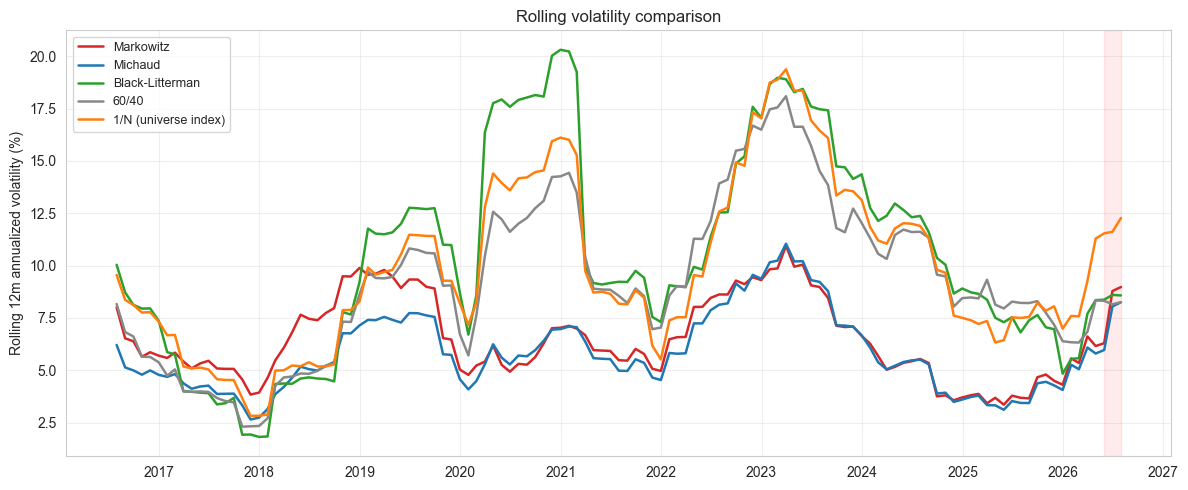

In [60]:
fig, ax = plt.subplots(figsize=(12, 5))
for name, (r, w) in strategies.items():
    roll_vol = r.rolling(12).std() * np.sqrt(MONTHS_PER_YEAR)
    ax.plot(roll_vol.index, roll_vol.values * 100, lw=1.8, label=name, color=colors_map.get(name))
ax.axvspan(pd.Timestamp('2026-06-01'), pd.Timestamp('2026-07-31'), color='red', alpha=0.08)
ax.set_ylabel('Rolling 12m annualized volatility (%)')
ax.set_title('Rolling volatility comparison')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()


## 14. Weight composition over time and AI-concentration diagnostics

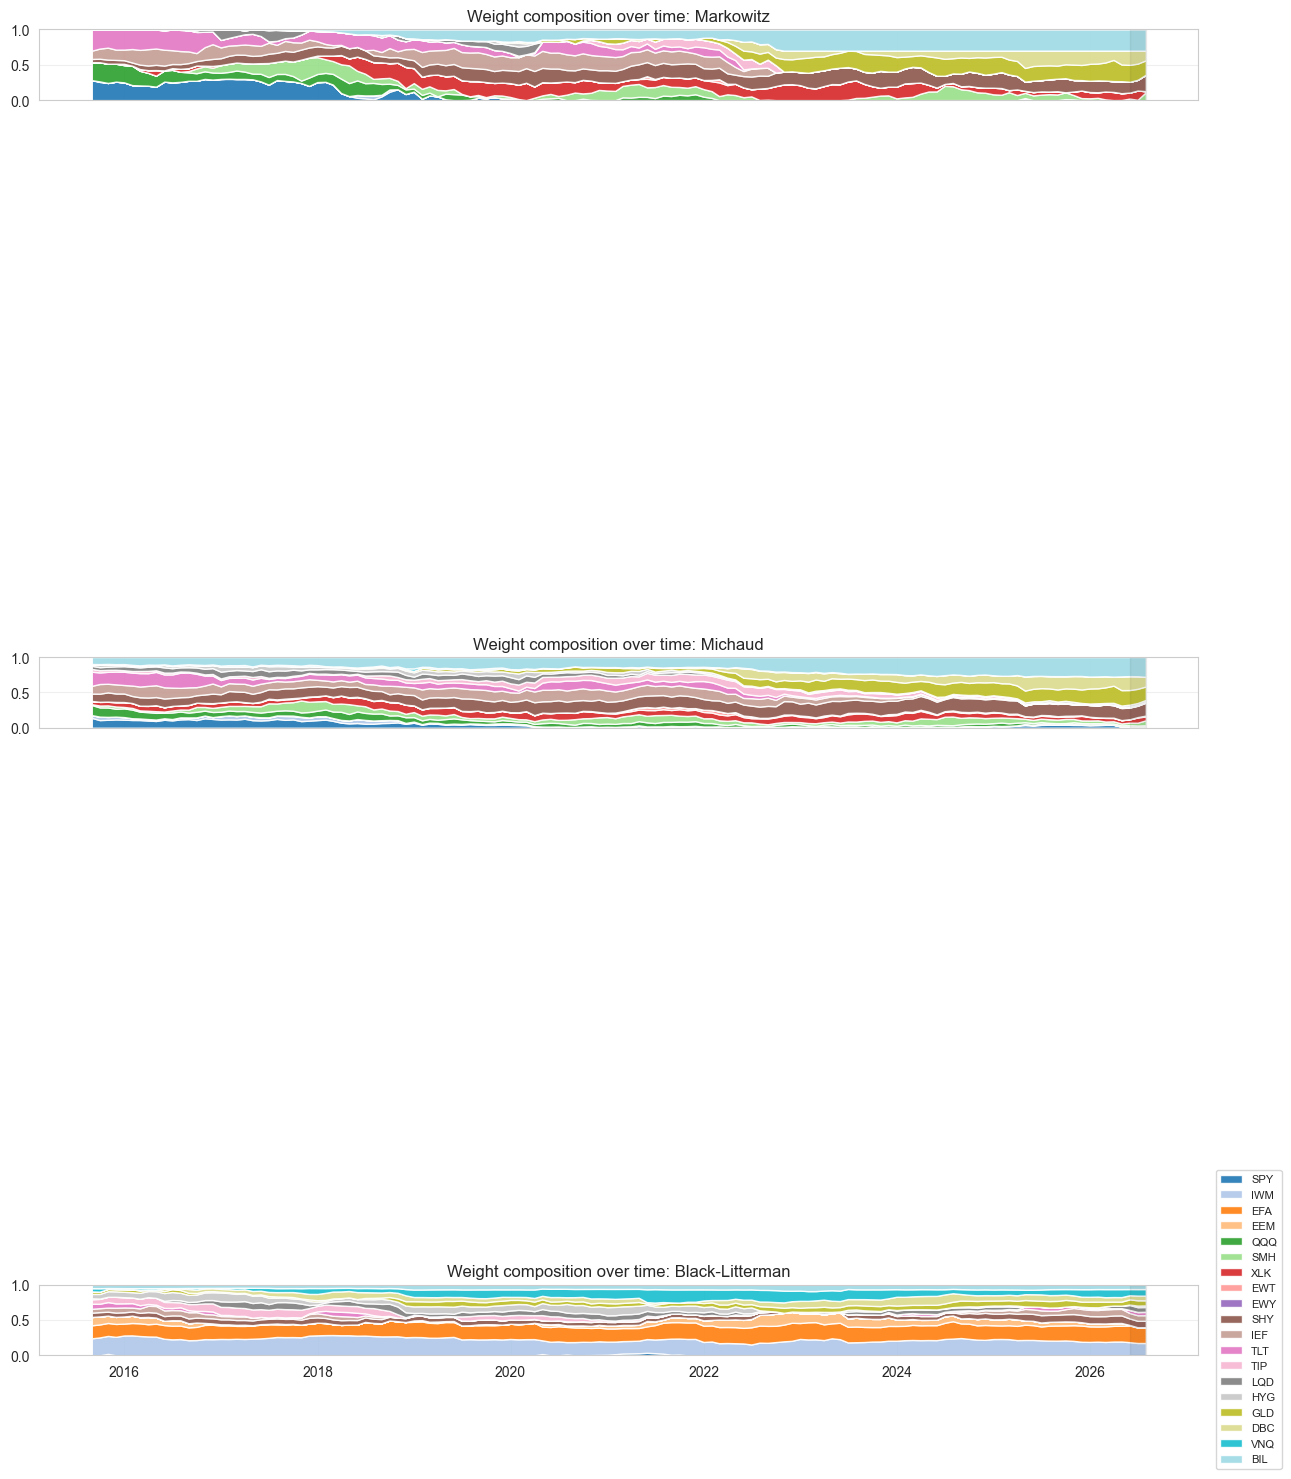

In [61]:
colors_assets = plt.cm.tab20(np.linspace(0, 1, n))
fig, axes = plt.subplots(3, 1, figsize=(13, 14), sharex=True)
for ax, (name, Wd) in zip(axes, [('Markowitz', W_mkw), ('Michaud', W_mic), ('Black-Litterman', W_bl)]):
    ax.stackplot(Wd.index, Wd.T.values.astype(float), labels=asset_names, colors=colors_assets, alpha=0.9)
    ax.set_ylim(0, 1)
    ax.set_title(f'Weight composition over time: {name}')
    ax.axvspan(pd.Timestamp('2026-06-01'), pd.Timestamp('2026-07-31'), color='black', alpha=0.06)
axes[-1].legend(loc='upper left', bbox_to_anchor=(1.01, 2.7), fontsize=8)
plt.tight_layout()
plt.show()


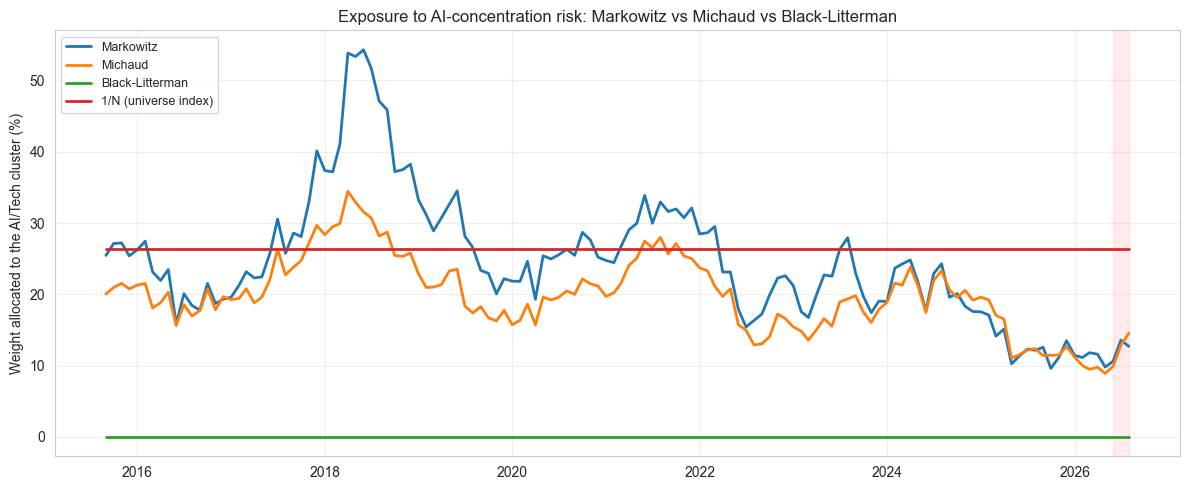

In [62]:
ai_cols = bucket_members['Equity_AI_Tech']
fig, ax = plt.subplots(figsize=(12, 5))
for name, Wd in [('Markowitz', W_mkw), ('Michaud', W_mic), ('Black-Litterman', W_bl), ('1/N (universe index)', W_1n)]:
    ai_weight = Wd[ai_cols].sum(axis=1)
    ax.plot(ai_weight.index, ai_weight.values * 100, lw=2, label=name)
ax.axvspan(pd.Timestamp('2026-06-01'), pd.Timestamp('2026-07-31'), color='red', alpha=0.08)
ax.set_ylabel('Weight allocated to the AI/Tech cluster (%)')
ax.set_title('Exposure to AI-concentration risk: Markowitz vs Michaud vs Black-Litterman')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()


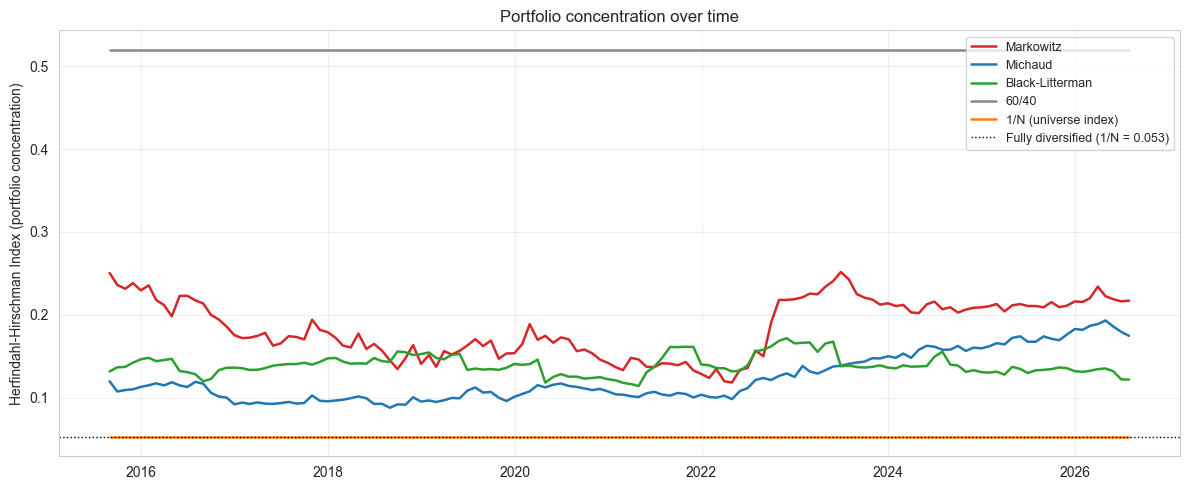

In [63]:
fig, ax = plt.subplots(figsize=(12, 5))
for name, (r, Wd) in strategies.items():
    hhi = (Wd ** 2).sum(axis=1)
    ax.plot(hhi.index, hhi.values, lw=1.8, label=name, color=colors_map.get(name))
ax.axhline(1 / n, color='black', lw=1, ls=':', label=f'Fully diversified (1/N = {1/n:.3f})')
ax.set_ylabel('Herfindahl-Hirschman Index (portfolio concentration)')
ax.set_title('Portfolio concentration over time')
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()


## 15. Stress-window deep dive: June 2026 (and the February 2026 preview)

We isolate performance **only** over the stress window(s), which is the central empirical
test of this project: does managing AI-concentration risk (Michaud / Black-Litterman)
actually pay off when the AI trade itself corrects?


In [64]:
STRESS_START, STRESS_END = '2026-06-01', '2026-07-31'
MINI_START, MINI_END = '2026-02-01', '2026-02-28'

def window_perf(ret, start, end, name):
    r = ret.loc[start:end]
    if len(r) == 0:
        return pd.Series({'Cum. Return': np.nan, 'Max Drawdown': np.nan}, name=name)
    cum = (1 + r).cumprod()
    dd = cum / cum.cummax() - 1
    return pd.Series({'Cum. Return': cum.iloc[-1] - 1, 'Max Drawdown': dd.min()}, name=name)

stress_table = pd.concat([window_perf(r, STRESS_START, STRESS_END, name) for name, (r, w) in strategies.items()], axis=1)
stress_table['100% QQQ'] = window_perf(ret_qqq, STRESS_START, STRESS_END, '100% QQQ').values
print('June 2026 AI/semiconductor selloff window:')
display(stress_table.T.style.format('{:.2%}'))

mini_table = pd.concat([window_perf(r, MINI_START, MINI_END, name) for name, (r, w) in strategies.items()], axis=1)
mini_table['100% QQQ'] = window_perf(ret_qqq, MINI_START, MINI_END, '100% QQQ').values
print('February 2026 preview episode:')
display(mini_table.T.style.format('{:.2%}'))


June 2026 AI/semiconductor selloff window:


,Cum. Return,Max Drawdown
Markowitz,-5.23%,-0.69%
Michaud,-4.42%,-0.60%
Black-Litterman,-0.36%,0.00%
60/40,-0.74%,-0.22%
1/N (universe index),-2.03%,-1.86%
100% QQQ,-3.43%,-3.29%


February 2026 preview episode:


,Cum. Return,Max Drawdown
Markowitz,2.36%,0.00%
Michaud,2.29%,0.00%
Black-Litterman,3.09%,0.00%
60/40,0.46%,0.00%
1/N (universe index),3.33%,0.00%
100% QQQ,-2.37%,0.00%


**Reading the monthly-resolution limitation.** Because every strategy above is
rebalanced and measured monthly, the June 2026 shock -- concentrated in a handful of
sessions -- shows up as a single (possibly diluted) monthly observation. The daily
zoom-in below freezes each strategy's last pre-shock weights and applies them to daily
returns during the stress window, giving a sharper view of the shock's actual severity.


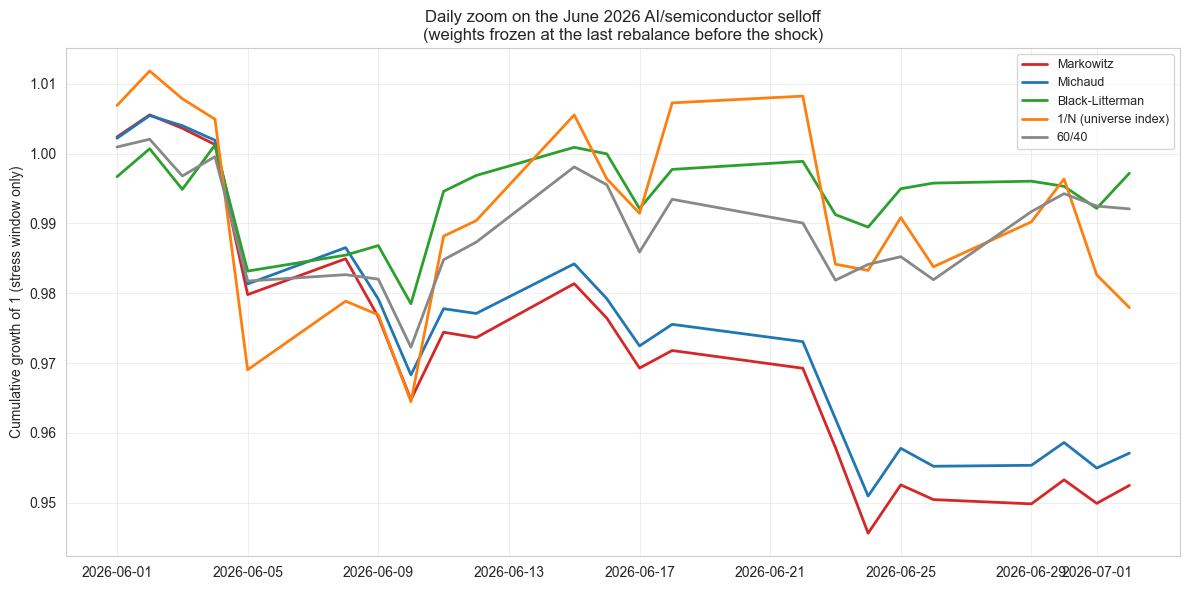

In [65]:
last_rebal_before = rebalance_dates[rebalance_dates < STRESS_START][-1]
daily_rets_stress = np.log(prices_daily / prices_daily.shift(1)).loc[STRESS_START:STRESS_END].dropna()

fig, ax = plt.subplots(figsize=(12, 6))
for name, Wd in [('Markowitz', W_mkw), ('Michaud', W_mic), ('Black-Litterman', W_bl),
                 ('1/N (universe index)', W_1n), ('60/40', W_6040)]:
    w_frozen = Wd.loc[last_rebal_before].values.astype(float)
    daily_port_ret = daily_rets_stress.values @ w_frozen
    cum = np.cumprod(1 + daily_port_ret)
    ax.plot(daily_rets_stress.index, cum, lw=2, label=name, color=colors_map.get(name))
ax.set_title('Daily zoom on the June 2026 AI/semiconductor selloff\n(weights frozen at the last rebalance before the shock)')
ax.set_ylabel('Cumulative growth of 1 (stress window only)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


## 16. Closing notes and suggested extensions

**What this notebook demonstrates**
- A fully rolling, no-look-ahead backtest engine reused identically across three
  optimization philosophies (Markowitz, Michaud, Black-Litterman) and two naive
  benchmarks, on a multi-asset universe deliberately built around the 2026
  AI-concentration theme.
- Concentration diagnostics (AI-cluster weight, portfolio HHI) that let you *see*, not
  just assume, whether resampling and BL views actually reduce unwanted thematic risk.
- A dedicated stress-window evaluation isolating the June 2026 AI/semiconductor selloff
  (and the February 2026 preview), which is where the value (or lack thereof) of robust
  construction should show up most clearly.

**Suggested extensions for the group presentation** (following the same pattern as
`Frontier_Robust.ipynb`):
- Sensitivity of the results to `WINDOW_MONTHS` (36 vs 60 vs 84), `COV_METHOD`
  ('sample' vs 'lw'), and `W_CAP` (20% vs 30% vs uncapped).
- Sensitivity of the Black-Litterman results to `TAU` and to the magnitude/confidence of
  the AI-concentration view (`Q_view`, `Omega` scaling), exactly as in section 9 of the
  course's `Black_Litterman.ipynb`.
- A quarterly-rebalancing variant (`REBAL_EVERY = 3`) to check whether the conclusions
  survive lower turnover.
- An asset-class **budget constraint** (e.g. cap the AI/Tech bucket at 25% of the
  portfolio) as an alternative, more direct way of managing concentration risk, to compare
  against the "let the optimizer decide" approach used here.
